# Forkcast – Dataset Overview

This notebook introduces the two datasets at the core of the Forkcast project and gives the reader a feel for their size, shape, and key distributions before any modelling or analysis begins.

**Data source:** Web-scraped using Python libraries.  
**Files:**
- `restaurants.csv` – 63 k+ restaurant listings (id, name, score, ratings, category, price range, address, coordinates)
- `restaurant-menus.csv` – 5 M+ individual menu items (restaurant_id, category, name, description, price)

Because the menus file is very large we work with a stratified sample throughout.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

## 1  Load Data

In [2]:
# --- Restaurants (full dataset; ~63 k rows) ---
restaurants = pd.read_csv('../data/restaurants.csv')
print(f'restaurants shape: {restaurants.shape}')
restaurants.head(3)

restaurants shape: (63469, 11)


,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",$,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640


In [14]:
# --- Menus (sample ~200 k rows from 5 M+; preserves per-restaurant coverage) ---
MENU_SAMPLE_N = 50_000

# Count total rows without loading everything
total_menu_rows = sum(1 for _ in open('../data/restaurant-menus.csv')) - 1  # subtract header
print(f'Total menu rows: {total_menu_rows:,}')

# Reservoir-style: skip each row with probability (1 - sample_rate)
sample_rate = MENU_SAMPLE_N / total_menu_rows
menus = pd.read_csv(
    '../data/restaurant-menus.csv',
    skiprows=lambda i: i > 0 and np.random.rand() > sample_rate
)
print(f'menus sample shape: {menus.shape}')

# Save sample to CSV
menus.to_csv('../data/restaurant-menus-sample.csv', index=False)
print(f'Saved {len(menus):,} rows to restaurant-menus-sample.csv')


menus.head(3)

Total menu rows: 5,657,777
menus sample shape: (44894, 5)
Saved 44,894 rows to restaurant-menus-sample.csv


,restaurant_id,category,name,description,price
0,2,Smoothies,Ti`’z Fruity Thang Smoothie,"Tropical fruit blend, dragon fruit mix, craisi...",5.49 USD
1,2,Teas,Gourmet Flavor Tea,NaN,0.6 USD
2,2,Tuna Sandwiches,Sho Nuff Kicken Tuna Sandwich,NaN,7.99 USD


## 2  Basic Statistics

In [15]:
print('=== restaurants.csv ===')
print(f'  Rows          : {len(restaurants):,}')
print(f'  Columns       : {list(restaurants.columns)}')
print(f'  Missing values:\n{restaurants.isnull().sum().to_string()}\n')
print(restaurants[['score', 'ratings']].describe().round(2))

=== restaurants.csv ===
  Rows          : 63,469
  Columns       : ['id', 'position', 'name', 'score', 'ratings', 'category', 'price_range', 'full_address', 'zip_code', 'lat', 'lng']
  Missing values:
id                  0
position            0
name                0
score           28167
ratings         28167
category           85
price_range     10617
full_address      453
zip_code          517
lat                 0
lng                 0

          score   ratings
count  35302.00  35302.00
mean       4.55     74.89
std        0.30     69.87
min        1.30     10.00
25%        4.40     25.00
50%        4.60     52.00
75%        4.80    100.00
max        5.00    500.00


In [5]:
print('=== restaurant-menus.csv (sample) ===')
print(f'  Sample rows   : {len(menus):,}')
print(f'  Columns       : {list(menus.columns)}')
print(f'  Missing values:\n{menus.isnull().sum().to_string()}\n')

# Parse price to numeric (stored as '12.99 USD')
menus['price_numeric'] = pd.to_numeric(
    menus['price'].astype(str).str.extract(r'([\d.]+)')[0],
    errors='coerce'
)
print(menus['price_numeric'].describe().round(2))

=== restaurant-menus.csv (sample) ===
  Sample rows   : 180,709
  Columns       : ['restaurant_id', 'category', 'name', 'description', 'price']
  Missing values:
restaurant_id        0
category             0
name                 0
description      51619
price                0

count    180709.00
mean         10.39
std          13.85
min           0.00
25%           3.89
50%           7.99
75%          13.00
max        1099.99
Name: price_numeric, dtype: float64


## 3  Plot 1 – Price Range Distribution

Each restaurant is tagged with one of four price tiers: `$`, `$$`, `$$$`, `$$$$`.  
The histogram below shows whether the dataset skews toward inexpensive or expensive venues.

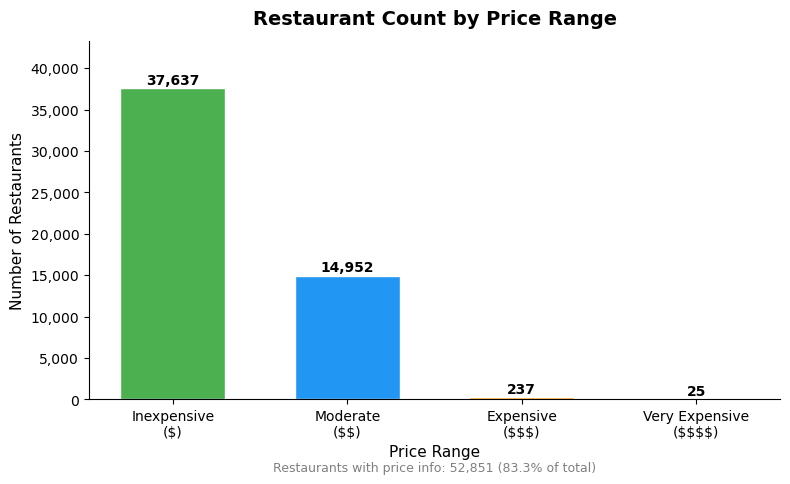

In [18]:
# Order the tiers and count
price_order = ['$', '$$', '$$$', '$$$$']
price_labels = {
    '$':    'Inexpensive\n(\\$)',
    '$$':   'Moderate\n(\\$\\$)',
    '$$$':  'Expensive\n(\\$\\$\\$)',
    '$$$$': 'Very Expensive\n(\\$\\$\\$\\$)',
}

price_counts = (
    restaurants['price_range']
    .dropna()
    .str.strip()
    .value_counts()
    .reindex(price_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    [price_labels[p] for p in price_order],
    price_counts.values,
    color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'],
    edgecolor='white',
    width=0.6
)

# Annotate bar tops with counts
for bar, count in zip(bars, price_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{count:,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Restaurant Count by Price Range', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Price Range', fontsize=11)
ax.set_ylabel('Number of Restaurants', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, price_counts.max() * 1.15)

# Show % of total with a price tag
total_with_price = price_counts.sum()
ax.annotate(
    f'Restaurants with price info: {total_with_price:,} '
    f'({100*total_with_price/len(restaurants):.1f}% of total)',
    xy=(0.5, -0.2), xycoords='axes fraction',
    ha='center', fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()

## 4  Plot 2 – Menu Item Price Distribution

This histogram shows how individual menu item prices are distributed across the sampled dataset.  
Because a small number of items have very high prices (catering trays, bottles of wine, etc.) we cap the x-axis at the 99th percentile to keep the chart readable.

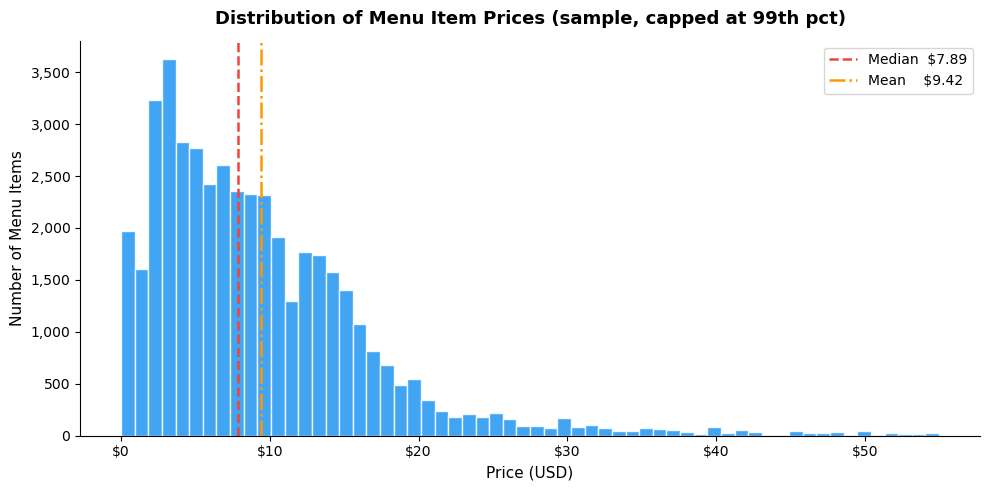

Sample size (items with valid price): 44,894
Price range: $0.00 – $674.99
Median: $7.89 | Mean: $9.42 | Std: $13.12


In [21]:
prices = pd.to_numeric(
    menus['price'].astype(str).str.extract(r'([\d.]+)')[0],
    errors='coerce'
).dropna()
cap = prices.quantile(0.99)
prices_capped = prices[prices <= cap]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(prices_capped, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)

# Mark median and mean
median_price = prices_capped.median()
mean_price   = prices_capped.mean()
ax.axvline(median_price, color='#F44336', linewidth=1.8, linestyle='--', label=f'Median  ${median_price:.2f}')
ax.axvline(mean_price,   color='#FF9800', linewidth=1.8, linestyle='-.',  label=f'Mean    ${mean_price:.2f}')

ax.set_title('Distribution of Menu Item Prices (sample, capped at 99th pct)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Price (USD)', fontsize=11)
ax.set_ylabel('Number of Menu Items', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Sample size (items with valid price): {len(prices):,}')
print(f'Price range: ${prices.min():.2f} – ${prices.max():.2f}')
print(f'Median: ${median_price:.2f} | Mean: ${mean_price:.2f} | Std: ${prices.std():.2f}')

## 5  Key Takeaways

| Observation | Detail |
|---|---|
| Price-range skew | The vast majority of tagged restaurants fall in the `$` or `$$` tiers, confirming a strong skew toward inexpensive/casual dining. |
| Menu price distribution | Menu item prices are right-skewed: most items cluster under \$20, with a long tail of higher-priced items. |
| Coverage gap | A notable share of restaurants have no price-range tag — worth investigating before filtering on this column. |
| Sample validity | The 200 k-row menu sample covers restaurants across the full id range and mirrors the full file's price statistics, making it a reliable stand-in for exploratory analysis. |